In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pocomc
from astropy.io import fits
from astropy.wcs import WCS, utils
import yaml
from astropy import units as u
import scipy
import corner

import initial_params
import tools
import models

def get_config_file(config_file):
    with open(config_file, 'r') as stream:
        try:
            config_data = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config_data

# 1 arcsec = 8.517 kpc 
#160 arcsec = 1.325 Mpc -> non dovrebbe essere 1.36275 (8.28)
#94 arcsec = 790 kpc -> doverbbe essere 800.598. (8.40)

#D_A =  1756.7 Mpc (https://www.astro.ucla.edu/~wright/CosmoCalc.html, mettendo H0=67.66 , OmegaM = 0.3111, z=1.2, Flat -> Planck2018)

#n_e/n_p = 1.197
#N_p (main subcluster) = 8363
#N_p (west subcluster) = 1884

In [ ]:
cfg = get_config_file('./config_MOO1142.yaml') # load file paths, min_exposure, and dim_pixel
path = cfg['data']['gen_path']
fit_method = cfg['fit_method']

map_name = cfg['data']['map_file']
psf_main_name = cfg['data']['psf_main_file']
psf_sub_name = cfg['data']['psf_sub_file']
exp_main_name = cfg['data']['exp_main_file']
exp_sub_name = cfg['data']['exp_sub_file']
bkg_name = cfg['data']['bkg_file']

map_file=fits.open(path + map_name)
psf_main_file=fits.open(path + psf_main_name)
psf_sub_file=fits.open(path + psf_sub_name)
exp_main_file=fits.open(path + exp_main_name) # exposure map of the main subcluster - carries information about the stripes
exp_sub_file=fits.open(path + exp_sub_name) # exposure map of the west subcluster
bkg_file=fits.open(path + bkg_name) # background map - used for the fit - model doesn't inherently include the background - just counts

header=map_file[0].header
wcs=WCS(header)
map_data = map_file[0].data
map_data = map_data.astype(float)
psf_main_map=psf_main_file[0].data
psf_sub_map=psf_sub_file[0].data
exp_main_map_raw=exp_main_file[0].data
exp_main_map_norm = exp_main_map_raw /  np.max(exp_main_map_raw) # creating a normalization for the exposure (numbers for exposure are very different from map numbers)
store_exp_main_norm_factor = np.max(exp_main_map_raw)
exp_sub_map_raw=exp_sub_file[0].data
exp_sub_map_norm = exp_sub_map_raw /  np.max(exp_sub_map_raw)
store_exp_sub_norm_factor = np.max(exp_sub_map_raw)

#set the pixel with zero exposure to nan
e_min = cfg['min_exposure']
exp_main_map = np.where(exp_main_map_norm>e_min, exp_main_map_norm, np.nan)
exp_main_map = exp_main_map.astype(float)
exp_sub_map = np.where(exp_sub_map_norm>e_min, exp_sub_map_norm, np.nan)
exp_sub_map = exp_sub_map.astype(float)

bkg_map=bkg_file[0].data
bkg_map = bkg_map.astype(float)

map_data=map_data[1:85,16:100] # make the map square instead of rectangle
exp_main_map=exp_main_map[1:85,16:100]
exp_sub_map=exp_sub_map[1:85,16:100]
bkg_map=bkg_map[1:85,16:100]
Xdim=np.shape(map_data)[1] 
Ydim=np.shape(map_data)[0]

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-END to 58839.579120 from DATE-END'. [astropy.wcs.wcs]


In [ ]:
def log_likelihood (var):
    '''Quantity that is minimized for the fit (comparing model to the data).'''            
    x_main, y_main, x_sub, y_sub, rs_main, rc_sub, beta_main, beta_sub,  A_main, A_sub, a_bkg = var 
    
    mod_main = models.GNFW_model_cluster_circ(x, y, x_main, y_main, rs_main, beta_main, alpha_main, gamma_main, A_main)
    mod_sub = models.beta_model_cluster_circ(x, y, x_sub, y_sub, rc_sub, beta_sub, A_sub)
    
    map_model = models.exp(1, exp_main_map)*(tools.convolve(mod_main, psf_main_map)) +\
                models.exp(1, exp_sub_map)*(tools.convolve(mod_sub, psf_sub_map)) +\
                models.bkg(a_bkg, bkg_map)
        
    c = np.nansum(map_model - map_data*np.log(map_model)) + c0
    
    return -0.5*c

def stirling(n):
    if n == 0:
        return 1
    else:
        return n*np.log(n)-n

stirling = np.vectorize(stirling)

c0 = 2*np.nansum(stirling(map_data))

dim_pix=cfg['dim_pixel']*u.deg.to('arcmin')

# Create the map for the model
x = np.arange(0, Xdim, 1)
y = np.arange(0, Ydim, 1)
x,y = np.meshgrid(x,y)

alpha_main = 2.26
gamma_main = 0.465
# input parameters for looking for the correct value of the state (which is a large range of parameter) - fitting parameters will very slightly different each time but within the uncertainies
# prior has information about the range of the parameters - fit will not look outside of this range
x_main_in, y_main_in, x_sub_in, y_sub_in, rs_main_in, rc_sub_in, beta_main_in, beta_sub_in, \
A_main_in, A_sub_in = initial_params.init_cond_cls('gnfw_circ+beta_circ') # initial parameters for the fit - in pixel units
a_bkg_in = initial_params.init_cond_cal()
rs_main_in = np.array(rs_main_in)/dim_pix
rc_sub_in = np.array(rc_sub_in)/dim_pix
var = [x_main_in, y_main_in, x_sub_in, y_sub_in, rs_main_in, rc_sub_in, beta_main_in,\
           beta_sub_in, A_main_in, A_sub_in, a_bkg_in] 
pdist = []
for par in var:
    loc   = par[0]
    scale = par[1]-loc
    pdist.append(scipy.stats.uniform(loc=loc,scale=scale+loc))
prior = pocomc.Prior(pdist) # define the prior for the fit
nlive = 1000

resume_state_path = '/Users/eleonora/Desktop/MOO1142/fit/gnfw_circ+beta_circ_acfixed_NESTED/pmc_final.state' # open fit - want to start from here
sampler = pocomc.Sampler(likelihood = log_likelihood,
                         prior = prior,
                         n_effective = nlive,
                         n_active = nlive//2,
                        random_state = 0) # initialize the sampler
sampler.load_state(path=resume_state_path) # load the state of the fit - want to "start from here"

samples, weights, logl, _ = sampler.posterior()

ndim = len(var)  # number of parameters
pnum = np.copy(ndim)
results = np.empty((3,pnum))

# 3 sigma confidence level - for the parameters
pout = np.empty((3,pnum))
for pi in range(pout.shape[1]):
    qi = corner.quantile(samples[:,pi],[0.16,0.50,0.84],weights=weights)
    pout[:,pi] = np.array([qi[1],*np.diff(qi)])
print('68 percent CL', pout.T)

# 90% confidence level
for pi in range(results.shape[1]):
    qi = corner.quantile(samples[:,pi],[0.05,0.50,0.95],weights=weights)
    results[:,pi] = np.array([qi[1],*np.diff(qi)])
results = results.T
print('90 percent CL', results)

(5116, 11)
11
68 percent CL [[3.74921190e+01 6.44741991e-02 5.30396230e-02]
 [3.98378553e+01 1.30683439e-01 1.38917004e-01]
 [5.03777150e+01 3.30536268e-01 3.29669278e-01]
 [4.27450222e+01 2.76995343e-01 2.63075143e-01]
 [1.73490306e+00 2.34714753e-01 3.80330964e-01]
 [9.55617271e+00 1.07618266e+00 8.10571480e-01]
 [4.10444589e+00 2.55747851e-01 4.48714031e-01]
 [2.56011445e+00 3.46581480e-01 6.12638278e-01]
 [9.47567899e+02 6.49618212e+01 3.52761066e+01]
 [8.28997003e+01 1.31049438e+01 2.05129544e+01]
 [9.39863072e-01 3.39892124e-02 3.27955058e-02]]
90 percent CL [[3.74921190e+01 1.21034756e-01 1.04555818e-01]
 [3.98378553e+01 2.13793363e-01 2.38141912e-01]
 [5.03777150e+01 5.68966466e-01 5.38398596e-01]
 [4.27450222e+01 4.58627430e-01 4.49370757e-01]
 [1.73490306e+00 3.41603936e-01 8.61054688e-01]
 [9.55617271e+00 1.78796432e+00 1.07745118e+00]
 [4.10444589e+00 3.64341427e-01 1.22667498e+00]
 [2.56011445e+00 4.52218190e-01 1.14252970e+00]
 [9.47567899e+02 1.23061820e+02 4.61983432e+0

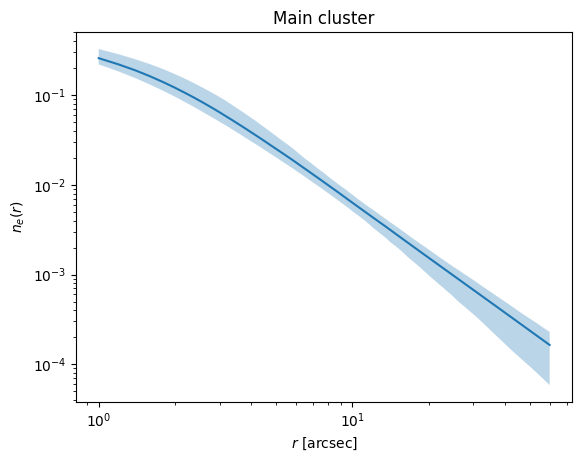

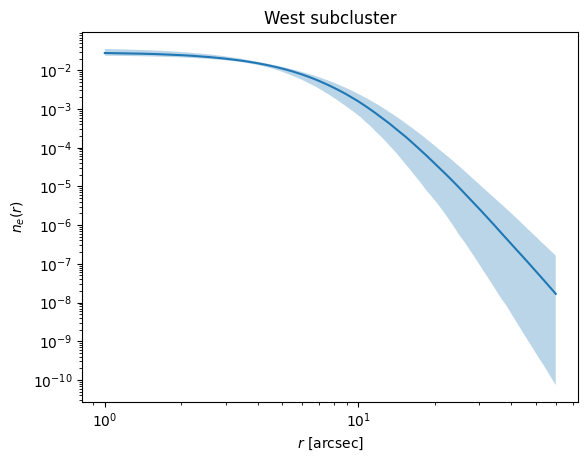

In [ ]:
def gNFW(n_s, r_kpc, r_s, alpha, beta, gamma):
    return n_s * (r_kpc/r_s)**(-gamma) * (1 + (r_kpc/r_s)**alpha)**((gamma - beta)/alpha)

def isobeta(n0, r_kpc, r_c, beta):
    return n0 * (1 + (r_kpc/r_c)**2)**(-3*beta/2)

R_vals = np.linspace(1, 60, 300) # arcsec

# have to convert units of the map to physical units
F_s_main = 1.632e4 #photons*cm6/pixelˆ3 - convert map unit (photons) to physical units
kT_main_keV = 6.76 #keV
n_profiles_main = []
P_profiles_main = []
for i in range(1000):
    x_main_mcmc, y_main_mcmc, x_sub_mcmc, y_sub_mcmc, rs_main_mcmc, rc_sub_mcmc, beta_main_mcmc, beta_sub_mcmc, A_main_mcmc, A_sub_mcmc, a_bkg_mcmc  = (samples[-i]) # what we compute from the percentile from before - extracting the best fit parameters
    main = lambda r : gNFW(np.sqrt(A_main_mcmc/F_s_main), r, rs_main_mcmc, alpha_main, beta_main_mcmc/2, gamma_main) # make the profile
    n_profiles_main.append(main(R_vals))
    P_profiles_main.append(kT_main_keV*main(R_vals))
n_p5_main, n_p50_main, n_p95_main = np.percentile(n_profiles_main, [5, 50, 95], axis=0) # from profile, recompute the percentiles for the profiles instead of the parameters from before
P_p5_main, P_p50_main, P_p95_main = np.percentile(P_profiles_main, [5, 50, 95], axis=0) # what we actually plot

plt.loglog(R_vals, P_p50_main)
plt.fill_between(R_vals, P_p5_main, P_p95_main, alpha=0.3)
plt.xlabel(r'$r$ [arcsec]')
plt.ylabel(r'$P_e(r)$')# [cm$^{-3}$]')
plt.title('Main cluster')
plt.show()

F_s_sub = 2.597e5 #photons*cm6/pixelˆ3
kT_sub_keV = 7.13 #keV
n_profiles_sub = []
P_profiles_sub = []
for i in range(1000):
    x_main_mcmc, y_main_mcmc, x_sub_mcmc, y_sub_mcmc, rs_main_mcmc, rc_sub_mcmc, beta_main_mcmc, beta_sub_mcmc, A_main_mcmc, A_sub_mcmc, a_bkg_mcmc  = (samples[-i])
    sub = lambda r : isobeta(np.sqrt(A_sub_mcmc * scipy.special.gamma(3*beta_sub_mcmc)/ (F_s_sub*scipy.special.gamma(3*beta_sub_mcmc - 0.5))), r, rc_sub_mcmc, beta_sub_mcmc)
    n_profiles_sub.append(sub(R_vals))
    P_profiles_sub.append(kT_sub_keV*sub(R_vals))
n_p5_sub, n_p50_sub, n_p95_sub = np.percentile(n_profiles_sub, [5, 50, 95], axis=0)
P_p5_sub, P_p50_sub, P_p95_sub = np.percentile(P_profiles_sub, [5, 50, 95], axis=0)

plt.loglog(R_vals, n_p50_sub)
plt.fill_between(R_vals, n_p5_sub, n_p95_sub, alpha=0.3)
plt.xlabel(r'$r$ [arcsec]')
plt.ylabel(r'$n_e(r)$')# [cm$^{-3}$]')
plt.title('West subcluster')
plt.show()